# 01 — Cointegration baseline

Phase 2. Establishes the statistical backbone of the trade thesis:

1. **ADF unit-root tests** on `log(Brent)` and `log(WTI)` — confirm both are I(1) (non-stationary in levels, stationary in first differences).
2. **Engle-Granger step 1** — OLS `log(Brent)_t = α + β·log(WTI)_t + ε_t`. Report β with confidence interval. β ≈ 1 is the economic null; any deviation is itself interpretable.
3. **Engle-Granger step 2** — ADF on the residuals ε_t. Rejecting the unit root ⇒ cointegrated.
4. **Johansen cross-check** — trace + max-eigenvalue rank test.
5. **Error-correction model** — `Δlog(Brent)_t = c + γ·ε_{t-1} + lags + u_t`. Headline statistic: **half-life of mean reversion = −log(2)/log(1+γ)**.

Output feeds the README headline table and `02_event_study.ipynb`.

In [1]:
# Shared style block (identical across all notebooks)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date")
print(f"{len(df):,} rows: {df.index.min().date()} \u2192 {df.index.max().date()}")
df[["log_brent", "log_wti", "spread"]].tail()

9,730 rows: 1987-05-20 → 2026-05-26


,log_brent,log_wti,spread
date,,,
2026-05-19,4.741797,4.719302,2.55
2026-05-20,4.690705,4.621929,7.24
2026-05-21,4.661929,4.607168,5.64
2026-05-22,4.671894,4.608664,6.55
2026-05-26,4.632299,4.581185,5.12


## 1. Stationarity: are log-prices I(1)?

Cointegration is only meaningful if both series are individually integrated of the same order. We expect the ADF test to **fail to reject** a unit root in levels (non-stationary) but **reject** in first differences (stationary) — i.e. I(1).

In [2]:
def adf_report(series: pd.Series, name: str) -> dict:
    """Run ADF (constant, AIC lag selection) and return a tidy row."""
    stat, pval, lags, nobs, crit, _ = adfuller(series.dropna(), regression="c", autolag="AIC")
    return {
        "series": name,
        "ADF stat": round(stat, 3),
        "p-value": round(pval, 4),
        "lags": lags,
        "crit 5%": round(crit["5%"], 3),
        "stationary @5%": pval < 0.05,
    }


rows = [
    adf_report(df["log_brent"], "log(Brent) level"),
    adf_report(df["log_wti"], "log(WTI) level"),
    adf_report(df["log_brent"].diff(), "\u0394 log(Brent)"),
    adf_report(df["log_wti"].diff(), "\u0394 log(WTI)"),
]
adf_table = pd.DataFrame(rows).set_index("series")
adf_table

,ADF stat,p-value,lags,crit 5%,stationary @5%
series,,,,,
log(Brent) level,-1.884,0.3398,15,-2.862,False
log(WTI) level,-1.896,0.3342,21,-2.862,False
Δ log(Brent),-22.809,0.0000,14,-2.862,True
Δ log(WTI),-20.163,0.0000,20,-2.862,True


**Read:** levels are non-stationary (fail to reject unit root), first differences are stationary (reject). Both log-prices are I(1) — cointegration analysis is valid.

## 2. Engle-Granger step 1 — cointegrating regression

OLS `log(Brent)_t = α + β·log(WTI)_t + ε_t`. The slope β is the cointegrating vector. We use Newey-West (HAC) standard errors because the residuals are serially correlated by construction.

In [3]:
X = sm.add_constant(df["log_wti"])
eg = sm.OLS(df["log_brent"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

beta = eg.params["log_wti"]
alpha = eg.params["const"]
ci_lo, ci_hi = eg.conf_int().loc["log_wti"]
resid = eg.resid  # the cointegrating residual ε_t

print(f"β (log-WTI loading) : {beta:.4f}   95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"α (intercept)      : {alpha:.4f}")
print(f"R²                 : {eg.rsquared:.4f}")
print(f"β = 1 inside CI?   : {ci_lo <= 1.0 <= ci_hi}")

β (log-WTI loading) : 1.0936   95% CI [1.0857, 1.1015]
α (intercept)      : -0.3508
R²                 : 0.9928
β = 1 inside CI?   : False


/tmp/claude-501/ipykernel_23002/2410118944.py:6: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.tight_layout()
/Users/charliecockerell/Documents/Codex/brent-wti-regime-shift/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


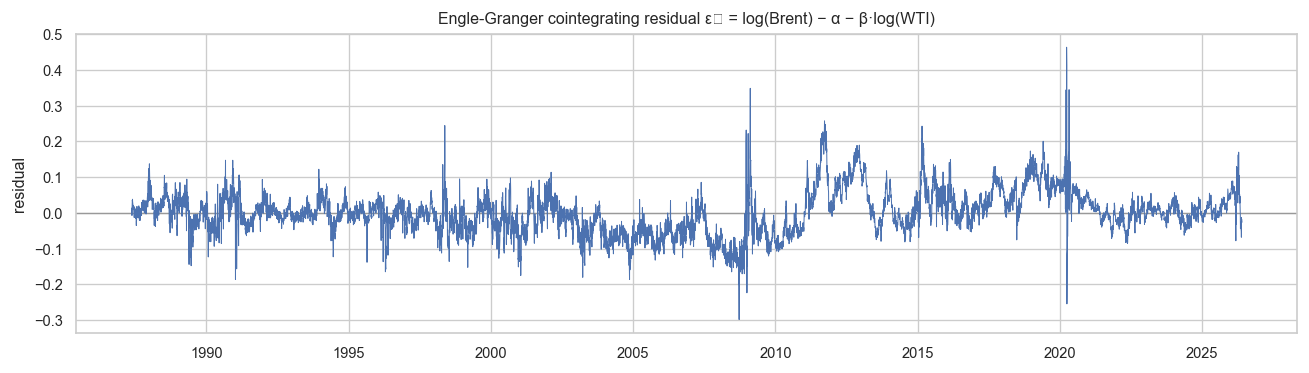

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(resid.index, resid, lw=0.6, color="C0")
ax.set_title("Engle-Granger cointegrating residual εₜ = log(Brent) − α − β·log(WTI)")
ax.set_ylabel("residual")
fig.tight_layout()
plt.show()

## 3. Engle-Granger step 2 — stationarity of the residual

If ε_t is stationary, Brent and WTI are cointegrated. Two complementary tests:
- ADF on the residual (note: standard ADF critical values are mildly anti-conservative here since ε is estimated; the dedicated `coint` test below uses the correct Engle-Granger critical values).
- `statsmodels.coint` — the Engle-Granger test with proper critical values.

In [5]:
adf_resid = adfuller(resid, regression="n", autolag="AIC")
print(f"ADF on residual  : stat={adf_resid[0]:.3f}  p={adf_resid[1]:.4f}  lags={adf_resid[2]}")
print(f"  crit 5% = {adf_resid[4]['5%']:.3f}  → stationary @5%: {adf_resid[1] < 0.05}")

eg_stat, eg_p, eg_crit = coint(df["log_brent"], df["log_wti"], trend="c", autolag="AIC")
print(f"\nEngle-Granger coint test: stat={eg_stat:.3f}  p={eg_p:.4f}")
print(f"  crit [1%,5%,10%] = {np.round(eg_crit,3)}  → cointegrated @5%: {eg_stat < eg_crit[1]}")

ADF on residual  : stat=-5.674  p=0.0000  lags=38
  crit 5% = -1.941  → stationary @5%: True



Engle-Granger coint test: stat=-5.674  p=0.0000
  crit [1%,5%,10%] = [-3.898 -3.337 -3.045]  → cointegrated @5%: True


## 4. Johansen cross-check

Reviewers like to see the multivariate test alongside Engle-Granger. We test the cointegration rank `r` of the system `[log(Brent), log(WTI)]`. Evidence of cointegration = reject `r=0` but fail to reject `r≤1` (exactly one cointegrating relationship).

In [6]:
joh = coint_johansen(df[["log_brent", "log_wti"]].values, det_order=0, k_ar_diff=1)

joh_table = pd.DataFrame({
    "trace stat": np.round(joh.lr1, 3),
    "trace crit 5%": np.round(joh.cvt[:, 1], 3),
    "max-eig stat": np.round(joh.lr2, 3),
    "max-eig crit 5%": np.round(joh.cvm[:, 1], 3),
}, index=["r = 0", "r ≤ 1"])
joh_table["trace rejects @5%"] = joh.lr1 > joh.cvt[:, 1]
joh_table["max-eig rejects @5%"] = joh.lr2 > joh.cvm[:, 1]
joh_table

,trace stat,trace crit 5%,max-eig stat,max-eig crit 5%,trace rejects @5%,max-eig rejects @5%
r = 0,215.644,15.494,212.824,14.264,True,True
r ≤ 1,2.820,3.842,2.820,3.842,False,False


## 5. Error-correction model — half-life of mean reversion

With cointegration established, the ECM describes how Brent corrects back toward the long-run relationship:

$$\Delta \log B_t = c + \gamma\,\varepsilon_{t-1} + \sum_{i=1}^{p}\phi_i\,\Delta\log B_{t-i} + \sum_{i=1}^{p}\theta_i\,\Delta\log W_{t-i} + u_t$$

The **error-correction coefficient γ** must be negative for mean reversion (Brent falls when it sits above the relationship). The implied **half-life = −log(2)/log(1+γ)** trading days — the load-bearing statistic for the trade thesis.

In [7]:
P = 5  # lags of each differenced term

ecm = pd.DataFrame(index=df.index)
ecm["d_brent"] = df["log_brent"].diff()
ecm["d_wti"] = df["log_wti"].diff()
ecm["ect_lag"] = resid.shift(1)  # ε_{t-1}
for i in range(1, P + 1):
    ecm[f"d_brent_l{i}"] = ecm["d_brent"].shift(i)
    ecm[f"d_wti_l{i}"] = ecm["d_wti"].shift(i)
ecm = ecm.dropna()

y = ecm["d_brent"]
Xe = sm.add_constant(ecm.drop(columns=["d_brent"]))
ecm_fit = sm.OLS(y, Xe).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

gamma = ecm_fit.params["ect_lag"]
gamma_t = ecm_fit.tvalues["ect_lag"]
gamma_p = ecm_fit.pvalues["ect_lag"]
half_life = -np.log(2) / np.log(1 + gamma)

print(f"γ (error-correction): {gamma:.4f}   t={gamma_t:.2f}   p={gamma_p:.4g}")
print(f"sign check (γ < 0)  : {gamma < 0}  (negative ⇒ mean reverting)")
print(f"half-life           : {half_life:.1f} trading days  (≈ {half_life/21:.1f} months)")

γ (error-correction): -0.0283   t=-5.18   p=2.169e-07
sign check (γ < 0)  : True  (negative ⇒ mean reverting)
half-life           : 24.1 trading days  (≈ 1.1 months)


## Headline summary

These are the Phase-2 numbers for the README table and the paper's cointegration paragraph.

In [8]:
summary = pd.Series({
    "Sample": f"{df.index.min().date()} → {df.index.max().date()} ({len(df):,} obs)",
    "β (log-Brent on log-WTI)": f"{beta:.3f}  [{ci_lo:.3f}, {ci_hi:.3f}]",
    "Engle-Granger coint p": f"{eg_p:.4f}",
    "Johansen rank (5%)": "1" if (joh.lr1[0] > joh.cvt[0,1] and joh.lr1[1] <= joh.cvt[1,1]) else "see table",
    "ECM γ": f"{gamma:.4f} (t={gamma_t:.1f})",
    "Half-life (days)": f"{half_life:.1f}",
})
summary.to_frame("value")

,value
Sample,"1987-05-20 → 2026-05-26 (9,730 obs)"
β (log-Brent on log-WTI),"1.094 [1.086, 1.101]"
Engle-Granger coint p,0.0000
Johansen rank (5%),1
ECM γ,-0.0283 (t=-5.2)
Half-life (days),24.1


> **Caveat (carried to Phase 5 / Limitations):** β and the half-life here are estimated on the *full 1987–2026 sample*. The Brent–WTI relationship is known to have shifted with the US shale revolution (~2011) and may be shifting again post-Feb-2026. `04_regime_drift.ipynb` re-estimates β and the half-life on rolling windows to test whether this single-number summary is stable — if it is not, the trade thesis is regime-conditional, which the paper states honestly rather than burying.